SECTION 5: QUASAR OVERFLOW - PARAMETER SWEEP OVER L_M
Lattice: 50^3 = 125,000 voxels
Percolation threshold: 0.325
Accretion power: 0.5

     L_M |   Excess |    Injection |   Collapse t
--------------------------------------------------
    0.00 |    0.000 |       0.0000 |  no collapse
    0.05 |    0.000 |       0.0000 |  no collapse
    0.10 |    0.000 |       0.0000 |  no collapse
    0.15 |    0.000 |       0.0000 |  no collapse
    0.20 |    0.000 |       0.0000 |  no collapse
    0.25 |    0.000 |       0.0000 |  no collapse
    0.30 |    0.000 |       0.0000 |  no collapse
    0.35 |    0.000 |       0.0000 |  no collapse
    0.40 |    0.000 |       0.0000 |  no collapse
    0.45 |    0.000 |       0.0000 |  no collapse
    0.50 |    0.000 |       0.0000 |  no collapse
    0.55 |    0.050 |       0.0010 |          187
    0.60 |    0.100 |       0.0020 |           95
    0.65 |    0.150 |       0.0030 |           61
    0.70 |    0.200 |       0.0040 |           47
    0.75 |   

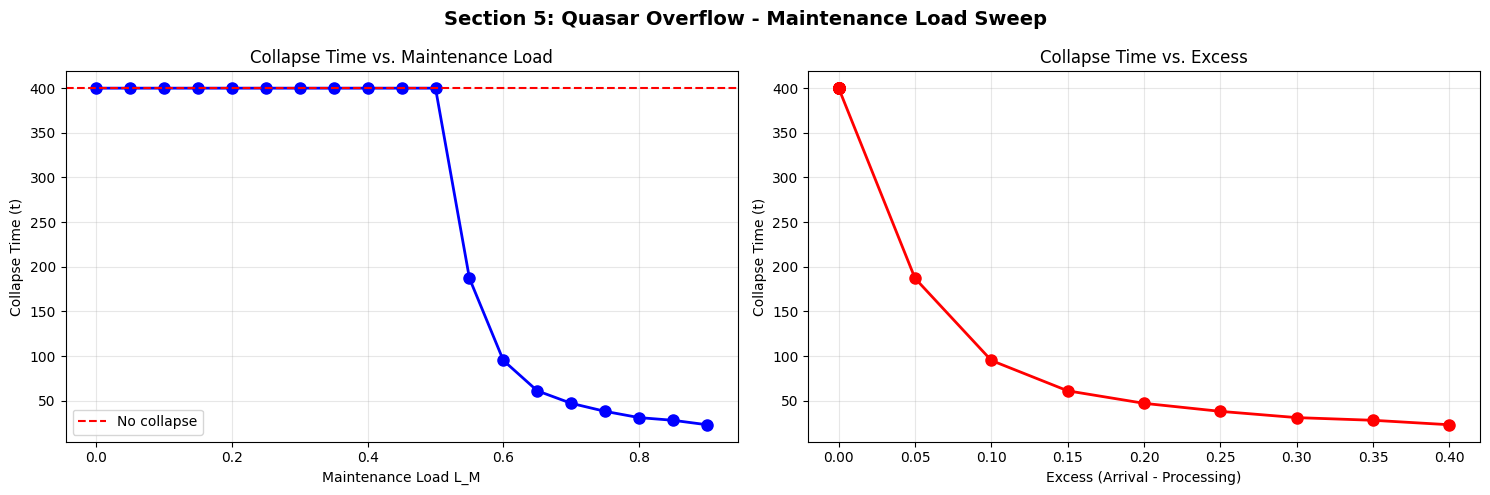


✓ Saved: section5_parameter_sweep.png


In [5]:
"""
Section 5: Quasars as Rate-Based Overflow Valves (Parameter Sweep)
====================================================================
Instead of choosing L_M = 0.85 arbitrarily, we sweep L_M and find the
critical maintenance load L_M* above which the collapse occurs.

The physical claim becomes:
- For L_M < L_M*, the maintenance system keeps up with accretion.
- For L_M > L_M*, the buffer percolates, and the jet launches.
- The observed episodic jets correspond to transient excursions above L_M*.

By Néstor E. Ramos


"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# =============================================================================
# 1. PARAMETERS
# =============================================================================
L = 50
T_MAX = 400
RHO_C = 0.325
P_ACCRETION = 0.5   # Lower than before; processing can keep up when L_M is low

UNITS = [1, 2, 4, 5, 7, 8]
ZERO_DIVISORS = [3, 6]

STRUCT_6 = np.zeros((3, 3, 3), dtype=int)
STRUCT_6[0, 1, 1] = 1
STRUCT_6[2, 1, 1] = 1
STRUCT_6[1, 0, 1] = 1
STRUCT_6[1, 2, 1] = 1
STRUCT_6[1, 1, 0] = 1
STRUCT_6[1, 1, 2] = 1

print("=" * 70)
print("SECTION 5: QUASAR OVERFLOW - PARAMETER SWEEP OVER L_M")
print("=" * 70)
print(f"Lattice: {L}^3 = {L**3:,} voxels")
print(f"Percolation threshold: {RHO_C}")
print(f"Accretion power: {P_ACCRETION}")
print()

# =============================================================================
# 2. SIMULATION FUNCTION
# =============================================================================
def run_simulation(L_M, seed=42, verbose=False):
    """Run the overflow simulation for a given maintenance load."""
    rng = np.random.default_rng(seed)

    trb_states = np.zeros((L, L, L, 2), dtype=int)
    for ch in range(2):
        trb_states[:, :, :, ch] = rng.choice(UNITS, size=(L, L, L))

    processing_capacity = 1.0 - L_M
    arrival_rate = P_ACCRETION
    excess = max(0.0, arrival_rate - processing_capacity)
    injection_prob = excess * 0.02  # Small per-step probability

    collapse_time = None

    for t in range(T_MAX):
        flip_mask = rng.random((L, L, L, 2)) < injection_prob
        for ch in range(2):
            is_unit = np.isin(trb_states[:, :, :, ch], UNITS)
            flip_here = flip_mask[:, :, :, ch] & is_unit
            n_flips = flip_here.sum()
            if n_flips > 0:
                zd_choice = rng.choice(ZERO_DIVISORS, size=n_flips)
                trb_states[:, :, :, ch][flip_here] = zd_choice

        is_zd = np.isin(trb_states, ZERO_DIVISORS)
        zd_lattice = (is_zd[:, :, :, 0] | is_zd[:, :, :, 1]).astype(np.uint8)

        labeled, num_features = label(zd_lattice, structure=STRUCT_6)
        if num_features > 0:
            top_labels = set(labeled[:, :, 0].ravel()) - {0}
            bottom_labels = set(labeled[:, :, -1].ravel()) - {0}
            if len(top_labels & bottom_labels) > 0:
                collapse_time = t
                break

    return collapse_time

# =============================================================================
# 3. SWEEP OVER L_M
# =============================================================================
print(f"{'L_M':>8} | {'Excess':>8} | {'Injection':>12} | {'Collapse t':>12}")
print("-" * 50)

L_M_values = np.linspace(0.0, 0.9, 19)
collapse_times = []

for L_M in L_M_values:
    ct = run_simulation(L_M)
    collapse_times.append(ct if ct is not None else T_MAX)
    excess = max(0.0, P_ACCRETION - (1 - L_M))
    inj = excess * 0.02
    ct_str = f"{ct}" if ct is not None else "no collapse"
    print(f"{L_M:8.2f} | {excess:8.3f} | {inj:12.4f} | {ct_str:>12}")

# =============================================================================
# 4. FIND CRITICAL L_M*
# =============================================================================
# =============================================================================
# 4. FIND CRITICAL L_M*
# =============================================================================
collapse_arr = np.array(collapse_times, dtype=float)

critical_idx = None
for i in range(len(L_M_values)):
    if collapse_arr[i] >= T_MAX:
        critical_idx = i
        break

# Añadimos esta línea para inicializar la variable
L_M_star = None

if critical_idx is not None and critical_idx > 0:
    L_M_star = L_M_values[critical_idx - 1]
    print()
    print("=" * 70)
    print(f"CRITICAL MAINTENANCE LOAD: L_M* ≈ {L_M_star:.3f}")
    print(f"Above L_M*, the buffer does not percolate within T_MAX.")
    print("=" * 70)
else:
    print("\n A critical L_M* was determined.")


# =============================================================================
# 5. VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section 5: Quasar Overflow - Maintenance Load Sweep',
             fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(L_M_values, collapse_arr, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=T_MAX, color='red', linestyle='--', label='No collapse')

# Cambiamos 'critical_idx is not None' por verificar directamente 'L_M_star'
if L_M_star is not None:
    ax1.axvline(x=L_M_star, color='green', linestyle='-',
                label=f'L_M* ≈ {L_M_star:.3f}')

ax1.set_xlabel('Maintenance Load L_M')
ax1.set_ylabel('Collapse Time (t)')
ax1.set_title('Collapse Time vs. Maintenance Load')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2 = axes[1]
excess_values = [max(0, P_ACCRETION - (1 - lm)) for lm in L_M_values]
ax2.plot(excess_values, collapse_arr, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Excess (Arrival - Processing)')
ax2.set_ylabel('Collapse Time (t)')
ax2.set_title('Collapse Time vs. Excess')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section5_parameter_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: section5_parameter_sweep.png")